# Mamba2 — Bayesian Context Features

Same architecture as `mamba_gap_prediction.ipynb` but **Level-5 context features
swap from MAUT gap scores → Bayesian posterior summaries** (θ latent overlookedness).

| Old L5 (MAUT) | New L5 (Bayesian) |
|---|---|
| gap_score_balanced/cerf/echo/usaid/ngo | theta_median, theta_ci_lo/hi/width |
| median_rank, rank_iqr | completeness |

**Reference:** MAUT Mamba2 → MAE=0.1224, RMSE=0.2223, UFE@10=8/10

### Upload these 7 files when prompted:
1. `monthly_severity_sequences.npy`  — from `Data/`
2. `sequence_countries.csv`          — from `Data/`
3. `sequence_snapshots.csv`          — from `Data/`
4. `enriched_frame_2025.csv`         — from `Data/`
5. `cerf_ufe.csv`                    — from `Data/Third-Party/Benchmarks/`
6. `care_bts.csv`                    — from `Data/Third-Party/Benchmarks/`
7. `analysis_code.zip`              — from `bayesian_features/`

In [1]:
# Install deps
!pip install numpyro jax einops -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 23.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
import zipfile, os

print('Upload 7 files: monthly_severity_sequences.npy, sequence_countries.csv,')
print('sequence_snapshots.csv, enriched_frame_2025.csv, cerf_ufe.csv, care_bts.csv,')
print('analysis_code.zip')

uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'/content/{fname}', 'wb') as f:
        f.write(data)
    print(f'Saved {fname} ({len(data)/1024:.1f} KB)')

# Unzip analysis code
if os.path.exists('/content/analysis_code.zip'):
    with zipfile.ZipFile('/content/analysis_code.zip', 'r') as z:
        z.extractall('/content/')
    print('Extracted analysis_code.zip → /content/analysis/')

Upload 7 files: monthly_severity_sequences.npy, sequence_countries.csv,
sequence_snapshots.csv, enriched_frame_2025.csv, cerf_ufe.csv, care_bts.csv,
analysis_code.zip


Extracted analysis_code.zip → /content/analysis/


In [3]:
import warnings, sys
warnings.filterwarnings('ignore')
sys.path.insert(0, '/content')
sys.path.insert(0, '/content/analysis')

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange, repeat

DATA   = Path('/content')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda  |  PyTorch: 2.10.0+cu128
GPU: Tesla T4


## 1. Compute Bayesian θ posteriors (~60-90s on CPU)

Fits the hierarchical latent-variable model (SVI, AutoMultivariateNormal, 8000 steps)
on the 6 MAUT attributes from the enriched frame. Outputs per-country:
- `theta_median` — posterior median (higher = more overlooked)
- `theta_ci_lo/hi` — 90% credible interval
- `theta_ci_width` — CI width (uncertainty proxy)

In [4]:
enriched_raw = pd.read_csv(DATA / 'enriched_frame_2025.csv', index_col=0)

THETA_CACHE = DATA / 'bayesian_theta_cache.parquet'
if THETA_CACHE.exists():
    print('Loading cached theta posteriors...')
    theta_df = pd.read_parquet(THETA_CACHE)
else:
    print('Fitting Bayesian hierarchical model...')
    from aggregations.composites import compute_overlookedness_posterior
    theta_df = compute_overlookedness_posterior(enriched_raw)
    theta_df.to_parquet(THETA_CACHE)
    print('Cached to bayesian_theta_cache.parquet')

enriched = enriched_raw.copy()
for col in ['theta_median', 'theta_ci_lo', 'theta_ci_hi', 'theta_ci_width', 'completeness']:
    if col in theta_df.columns:
        enriched[col] = theta_df[col]

hrp = enriched['theta_median'].notna()
print(f'\nHRP-eligible countries with theta: {hrp.sum()} / {len(enriched)}')
print(enriched.loc[hrp, ['theta_median','theta_ci_lo','theta_ci_hi','theta_ci_width']].describe().round(3))

Fitting Bayesian hierarchical model...
Cached to bayesian_theta_cache.parquet

HRP-eligible countries with theta: 22 / 114
       theta_median  theta_ci_lo  theta_ci_hi  theta_ci_width
count        22.000       22.000       22.000          22.000
mean          0.561        0.322        0.793           0.471
std           0.033        0.041        0.031           0.018
min           0.469        0.208        0.721           0.441
25%           0.545        0.303        0.779           0.459
50%           0.561        0.321        0.791           0.468
75%           0.579        0.340        0.806           0.483
max           0.650        0.423        0.881           0.513


## 2. Data pipeline — same sequences, new context

In [5]:
X_monthly = np.load(DATA / 'monthly_severity_sequences.npy')   # (75, 65, 4)
countries  = pd.read_csv(DATA / 'sequence_countries.csv',  header=None)[0].tolist()
snapshots  = pd.read_csv(DATA / 'sequence_snapshots.csv',  header=None)[0].tolist()
cerf_ufe   = pd.read_csv(DATA / 'cerf_ufe.csv')
care_bts   = pd.read_csv(DATA / 'care_bts.csv')
N, T, F_seq = X_monthly.shape

# ── Context: L1-L4 structural/temporal + L5 Bayesian (replaces MAUT gap scores)
CTX_COLS = [
    'need_intensity', 'coverage_shortfall', 'coverage', 'per_pin_allocated',  # L2
    'cluster_gini', 'donor_hhi', 'cbpf_reliance',                             # L3
    'severity_baseline_24m', 'severity_acute_delta_3m',                       # L4
    'severity_volatility_12m', 'severity_trend_12m',
    'coverage_baseline_3y', 'coverage_trend_3y',
    'displaced_growth_12m', 'persistence_P4_plus',
    'theta_median', 'theta_ci_lo', 'theta_ci_hi', 'theta_ci_width',           # L5 NEW
    'completeness',
]
CTX_COLS = [c for c in CTX_COLS if c in enriched.columns]
F_ctx = len(CTX_COLS)
print(f'Context features: {F_ctx}  (MAUT version had 21)')
print(f'  Bayesian L5: {[c for c in CTX_COLS if "theta" in c or c=="completeness"]}')

ctx_arr = enriched.reindex(countries)[CTX_COLS].values.astype(np.float64)
ctx_med = np.nanmedian(ctx_arr, axis=0)
for j in range(F_ctx):
    ctx_arr[:, j] = np.where(np.isnan(ctx_arr[:, j]), ctx_med[j], ctx_arr[:, j])
ctx_norm = StandardScaler().fit_transform(ctx_arr).astype(np.float32)

seq_flat   = X_monthly[:, :48, :].reshape(-1, F_seq)
X_norm = StandardScaler().fit(seq_flat).transform(
    X_monthly.reshape(-1, F_seq)).reshape(N, T, F_seq).astype(np.float32)

SEQ_LEN, PRED_STEPS = 24, 3
seqs_X, seqs_ctx, seqs_y, seqs_meta = [], [], [], []
for i, iso3 in enumerate(countries):
    for t in range(SEQ_LEN, T - PRED_STEPS):
        seqs_X.append(X_norm[i, t-SEQ_LEN:t])
        seqs_ctx.append(ctx_norm[i])
        seqs_y.append(float(np.mean(X_monthly[i, t:t+PRED_STEPS, 0])))
        seqs_meta.append({'iso3': iso3, 'end_snapshot': snapshots[t]})

X_arr   = np.stack(seqs_X).astype(np.float32)
ctx_mat = np.stack(seqs_ctx).astype(np.float32)
y_arr   = np.array(seqs_y, dtype=np.float32)
meta_df = pd.DataFrame(seqs_meta)
train_mask = meta_df['end_snapshot'] < '2025-01'
train_idx  = meta_df[train_mask].index.tolist()
test_idx   = meta_df[~train_mask].index.tolist()

neglect_map = {iso3: {
    'neglected': float(not pd.isna(enriched.loc[iso3,'coverage']) and enriched.loc[iso3,'coverage'] < 0.4),
    'gap_score': float(enriched.loc[iso3,'theta_median'])
                 if 'theta_median' in enriched.columns and not pd.isna(enriched.loc[iso3,'theta_median']) else 0.
} for iso3 in countries if iso3 in enriched.index}

y_neg = np.array([neglect_map.get(m['iso3'],{}).get('neglected',0.5) for m in seqs_meta], dtype=np.float32)
y_gap = np.array([neglect_map.get(m['iso3'],{}).get('gap_score', 0.)  for m in seqs_meta], dtype=np.float32)
if y_gap.std() > 0:
    y_gap = (y_gap - y_gap.min()) / (y_gap.max() - y_gap.min())

n_pos = float(y_neg[train_idx].sum()); n_neg = float(len(train_idx)) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos,1.)], dtype=torch.float32, device=DEVICE)
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}  Target: {y_arr.min():.1f}–{y_arr.max():.1f}')

Context features: 20  (MAUT version had 21)
  Bayesian L5: ['theta_median', 'theta_ci_lo', 'theta_ci_hi', 'theta_ci_width', 'completeness']
Train: 2025  Test: 825  Target: 2.0–5.0


## 3. Mamba2 — same architecture, F_ctx adapted

In [6]:
class SSDLayer(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, d_ctx=0):
        super().__init__()
        self.d_inner = d_model * expand; self._d_state = d_state
        dt_rank = max(1, d_model // 16); self.dt_rank = dt_rank
        self.in_proj  = nn.Linear(d_model, self.d_inner*2+d_state*2+dt_rank, bias=False)
        self.dt_proj  = nn.Linear(dt_rank, self.d_inner, bias=True)
        nn.init.uniform_(self.dt_proj.bias, -4, -1)
        A = repeat(torch.arange(1,d_state+1,dtype=torch.float32),'n->h n',h=self.d_inner)
        self.A_log = nn.Parameter(torch.log(A)); self.D = nn.Parameter(torch.ones(self.d_inner))
        self.conv1d   = nn.Conv1d(self.d_inner,self.d_inner,d_conv,padding=d_conv-1,groups=self.d_inner,bias=True)
        self.ctx_gate = nn.Linear(d_ctx, self.d_inner, bias=True) if d_ctx > 0 else None
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)

    def selective_scan(self, u, delta, A, B, C, D):
        B_b,L,d=u.shape; N=A.shape[1]
        dA=torch.exp(rearrange(delta,'b l d->b l d 1')*rearrange(A,'d n->1 1 d n'))
        dBu=rearrange(delta,'b l d->b l d 1')*rearrange(B,'b l n->b l 1 n')*rearrange(u,'b l d->b l d 1')
        h=torch.zeros(B_b,d,N,device=u.device,dtype=u.dtype); ys=[]
        for t in range(L):
            h=dA[:,t]*h+dBu[:,t]; ys.append((h*rearrange(C[:,t],'b n->b 1 n')).sum(-1))
        return torch.stack(ys,1)+u*D.unsqueeze(0).unsqueeze(0)

    def forward(self, x, ctx=None):
        residual=x; B,L,_=x.shape
        x_s,z,B_s,C_s,dt=torch.split(self.in_proj(x),
            [self.d_inner,self.d_inner,self._d_state,self._d_state,self.dt_rank],dim=-1)
        x_s=F.silu(self.conv1d(rearrange(x_s,'b l d->b d l'))[...,:L])
        x_s=rearrange(x_s,'b d l->b l d')
        dt_raw=self.dt_proj(dt)
        if self.ctx_gate is not None and ctx is not None:
            dt_raw=dt_raw+self.ctx_gate(ctx).unsqueeze(1)
        dt=F.softplus(dt_raw); A=-torch.exp(self.A_log)
        y=self.selective_scan(x_s,dt,A,B_s,C_s,self.D)
        return self.norm(self.out_proj(torch.nan_to_num(y)*F.silu(z))+residual)

class Mamba2Block(nn.Module):
    def __init__(self,d_model,d_ctx=0,dropout=0.1):
        super().__init__()
        self.ssm=SSDLayer(d_model,d_ctx=d_ctx)
        self.mlp=nn.Sequential(nn.LayerNorm(d_model),nn.Linear(d_model,d_model*2),
                                nn.GELU(),nn.Dropout(dropout),nn.Linear(d_model*2,d_model))
    def forward(self,x,ctx=None): return x+self.mlp(self.ssm(x,ctx=ctx))

class Mamba2Forecaster(nn.Module):
    def __init__(self,F_seq,F_ctx,d_model=48,n_layers=3,dropout=0.15):
        super().__init__()
        self.ctx_proj=nn.Sequential(nn.Linear(F_ctx,d_model),nn.LayerNorm(d_model),nn.GELU())
        self.input_proj=nn.Linear(F_seq,d_model)
        self.pos_emb=nn.Parameter(torch.zeros(1,64,d_model))
        nn.init.trunc_normal_(self.pos_emb,std=0.02)
        self.blocks=nn.ModuleList([Mamba2Block(d_model,d_ctx=d_model,dropout=dropout) for _ in range(n_layers)])
        self.dropout=nn.Dropout(dropout); self.norm=nn.LayerNorm(d_model)
        def h(): return nn.Sequential(nn.Linear(d_model*2,32),nn.GELU(),nn.Linear(32,1))
        self.sev_head=h(); self.gap_head=h(); self.neglect_head=h()

    def forward(self,x,ctx):
        B,L,_=x.shape
        h=self.dropout(self.input_proj(x)+self.pos_emb[:,:L,:])
        c=self.ctx_proj(ctx)
        for blk in self.blocks: h=blk(h,ctx=c)
        h=self.norm(h); pool=torch.cat([h[:,-1,:],h.mean(1)],dim=-1)
        return self.sev_head(pool).squeeze(-1),self.gap_head(pool).squeeze(-1),self.neglect_head(pool).squeeze(-1)

model=Mamba2Forecaster(F_seq=F_seq,F_ctx=F_ctx).to(DEVICE)
print(f'Mamba2Forecaster — {sum(p.numel() for p in model.parameters()):,} params  |  F_ctx={F_ctx}')

Mamba2Forecaster — 110,691 params  |  F_ctx=20


## 4. Training — identical config to mamba_gap_prediction.ipynb

In [7]:
class MultiTargetDataset(Dataset):
    def __init__(self,X,ctx,ys,yg,yn):
        self.X=torch.tensor(X,dtype=torch.float32); self.ctx=torch.tensor(ctx,dtype=torch.float32)
        self.ys=torch.tensor(ys,dtype=torch.float32); self.yg=torch.tensor(yg,dtype=torch.float32)
        self.yn=torch.tensor(yn,dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.ctx[i],self.ys[i],self.yg[i],self.yn[i]

train_ds=MultiTargetDataset(X_arr[train_idx],ctx_mat[train_idx],y_arr[train_idx],y_gap[train_idx],y_neg[train_idx])
test_ds =MultiTargetDataset(X_arr[test_idx], ctx_mat[test_idx], y_arr[test_idx], y_gap[test_idx], y_neg[test_idx])
train_loader=DataLoader(train_ds,64,shuffle=True); test_loader=DataLoader(test_ds,128)

EPOCHS,LR,PATIENCE=150,8e-4,30
W_SEV,W_GAP,W_NEG=0.5,0.3,0.2
opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=3e-3)
sched=torch.optim.lr_scheduler.OneCycleLR(opt,max_lr=LR,epochs=EPOCHS,
                                            steps_per_epoch=len(train_loader),pct_start=0.15)
tr_l,te_l,te_m=[],[],[]
best,state,pat=float('inf'),None,0; t0=time.time()

for epoch in range(EPOCHS):
    model.train(); ep=0.
    for X_b,ctx_b,ys_b,yg_b,yn_b in train_loader:
        X_b,ctx_b=X_b.to(DEVICE),ctx_b.to(DEVICE)
        ys_b,yg_b,yn_b=ys_b.to(DEVICE),yg_b.to(DEVICE),yn_b.to(DEVICE)
        sp,gp,nl=model(X_b,ctx_b)
        loss=(W_SEV*F.huber_loss(sp,ys_b,delta=0.5)+W_GAP*F.huber_loss(gp,yg_b,delta=0.5)+
              W_NEG*F.binary_cross_entropy_with_logits(nl,yn_b,pos_weight=pos_weight))
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),0.5)
        opt.step(); sched.step(); ep+=loss.item()

    model.eval(); tl=0.; p_,t_=[],[]
    with torch.no_grad():
        for X_b,ctx_b,ys_b,yg_b,yn_b in test_loader:
            X_b,ctx_b=X_b.to(DEVICE),ctx_b.to(DEVICE)
            ys_b,yg_b,yn_b=ys_b.to(DEVICE),yg_b.to(DEVICE),yn_b.to(DEVICE)
            sp,gp,nl=model(X_b,ctx_b)
            tl+=(W_SEV*F.huber_loss(sp,ys_b,delta=0.5)+W_GAP*F.huber_loss(gp,yg_b,delta=0.5)+
                 W_NEG*F.binary_cross_entropy_with_logits(nl,yn_b,pos_weight=pos_weight)).item()
            p_.extend(sp.cpu().numpy()); t_.extend(ys_b.cpu().numpy())

    tl/=len(test_loader); mae=mean_absolute_error(t_,p_)
    tr_l.append(ep/len(train_loader)); te_l.append(tl); te_m.append(mae)
    if tl<best: best,state,pat=tl,{k:v.clone() for k,v in model.state_dict().items()},0
    else:
        pat+=1
        if pat>=PATIENCE: print(f'Early stop ep={epoch}'); break
    if epoch%20==0: print(f'Ep {epoch:3d} | test={tl:.4f} | MAE={mae:.4f}')

model.load_state_dict(state)
print(f'\nBest loss={best:.4f}  ({time.time()-t0:.0f}s)')

Ep   0 | test=0.9883 | MAE=3.5956
Ep  20 | test=0.0134 | MAE=0.1562
Ep  40 | test=0.0142 | MAE=0.1560
Early stop ep=53

Best loss=0.0123  (89s)


## 5. Evaluation + CERF UFE overlap

=== Bayesian context Mamba2 ===
MAE:   0.1415  (MAUT ref: 0.1224)
RMSE:  0.2311  (MAUT ref: 0.2223)
vs Naive: 5.69×  (MAUT ref: 6.59×)


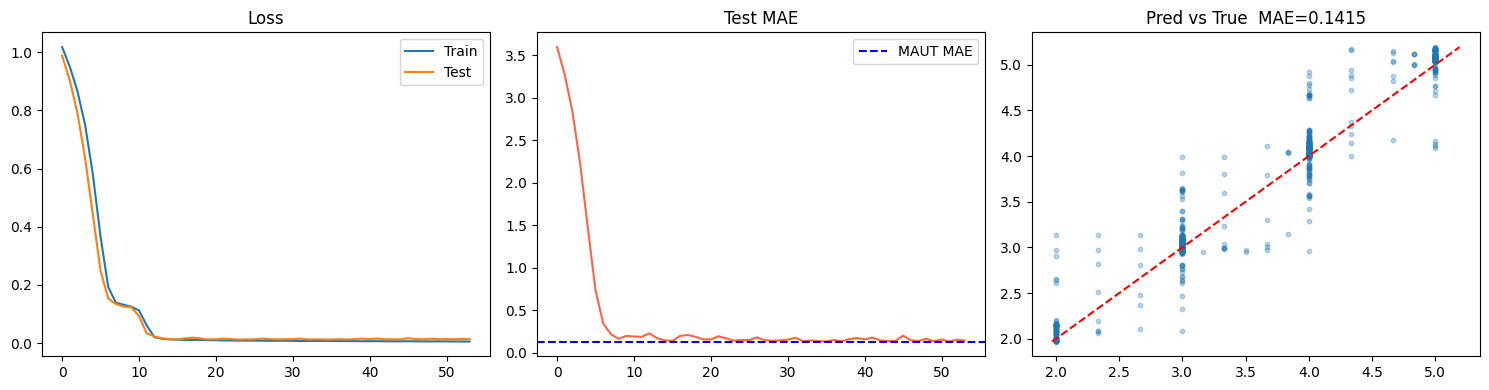


Crisis countries ranked: 66
  CERF UFE @5: 4/5   (MAUT Mamba2: 3/5, 8/10, 10/15)
  CERF UFE @10: 9/10   (MAUT Mamba2: 3/5, 8/10, 10/15)
  CERF UFE @15: 13/15   (MAUT Mamba2: 3/5, 8/10, 10/15)
  CARE BTS @10: 2/10  (MAUT: 2/10)

Top 15:
iso3  rank  current_severity  predicted_severity_3m  theta_median  theta_ci_width  composite_score
 SLV     1             3.000                  3.579         0.588           0.457            0.912
 CAF     2             4.000                  4.675         0.535           0.483            0.679
 COD     3             5.000                  5.181         0.544           0.484            0.678
 HND     4             4.000                  4.048         0.650           0.458            0.675
 YEM     5             5.000                  5.126         0.566           0.476            0.663
 MLI     6             5.000                  5.127         0.560           0.449            0.660
 BFA     7             5.000                  5.136         0.551     

In [8]:
model.eval(); p_,t_=[],[]
with torch.no_grad():
    for X_b,ctx_b,ys_b,*_ in test_loader:
        sp,_,_=model(X_b.to(DEVICE),ctx_b.to(DEVICE))
        p_.extend(sp.cpu().numpy()); t_.extend(ys_b.numpy())
pred=np.array(p_); true=np.array(t_)
mae=mean_absolute_error(true,pred); rmse=np.sqrt(mean_squared_error(true,pred))
naive=mean_absolute_error(true,np.full_like(true,true.mean()))

print('=== Bayesian context Mamba2 ===')
print(f'MAE:   {mae:.4f}  (MAUT ref: 0.1224)')
print(f'RMSE:  {rmse:.4f}  (MAUT ref: 0.2223)')
print(f'vs Naive: {naive/mae:.2f}×  (MAUT ref: 6.59×)')

fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].plot(tr_l,label='Train'); axes[0].plot(te_l,label='Test')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(te_m,color='tomato'); axes[1].axhline(0.1224,color='blue',ls='--',label='MAUT MAE')
axes[1].set_title('Test MAE'); axes[1].legend()
axes[2].scatter(true,pred,alpha=0.3,s=10)
lm=[min(true.min(),pred.min()),max(true.max(),pred.max())]
axes[2].plot(lm,lm,'r--'); axes[2].set_title(f'Pred vs True  MAE={mae:.4f}')
plt.tight_layout(); plt.savefig('/content/mamba_bayesian_training.png',dpi=150); plt.show()

# Country-level inference + CERF overlap
def safe_norm(s): mn,mx=s.min(),s.max(); return (s-mn)/(mx-mn) if mx>mn else pd.Series(0.,index=s.index)
model.eval(); rows=[]
for i,iso3 in enumerate(countries):
    xt=torch.tensor(X_norm[i,-SEQ_LEN:][None],dtype=torch.float32).to(DEVICE)
    ct=torch.tensor(ctx_norm[i][None],dtype=torch.float32).to(DEVICE)
    with torch.no_grad(): sp,_,nl=model(xt,ct)
    cur=float(X_monthly[i,-1,0])
    row={'iso3':iso3,'current_severity':cur,'predicted_severity_3m':float(sp.cpu()),
         'neglect_prob':float(torch.sigmoid(nl).cpu())}
    for col in ['theta_median','severity_baseline_24m','coverage_shortfall','theta_ci_width']:
        row[col]=enriched.loc[iso3,col] if iso3 in enriched.index and col in enriched.columns else np.nan
    row['severity_worsening']=max(0.,row['predicted_severity_3m']-cur)
    rows.append(row)

df=pd.DataFrame(rows)
df['theta_norm']=safe_norm(df['theta_median'].fillna(0))
df['sev_norm']=safe_norm(df['severity_worsening'].fillna(0))
df['neglect_norm']=safe_norm(df['neglect_prob'].fillna(0))
df['composite_score']=0.40*df['theta_norm']+0.35*df['sev_norm']+0.25*df['neglect_norm']
ranking=df[df['severity_baseline_24m'].fillna(0)>=3].sort_values('composite_score',ascending=False).reset_index(drop=True)
ranking['rank']=ranking.index+1

ufe=set(cerf_ufe['iso3']); bts=set(care_bts['iso3'])
print(f'\nCrisis countries ranked: {len(ranking)}')
for k in [5,10,15]:
    ov=len(set(ranking['iso3'].head(k))&ufe)
    print(f'  CERF UFE @{k}: {ov}/{k}   (MAUT Mamba2: 3/5, 8/10, 10/15)')
print(f'  CARE BTS @10: {len(set(ranking["iso3"].head(10))&bts)}/10  (MAUT: 2/10)')

print('\nTop 15:')
disp=[c for c in ['iso3','rank','current_severity','predicted_severity_3m','theta_median','theta_ci_width','composite_score'] if c in ranking.columns]
print(ranking[disp].head(15).to_string(index=False,float_format='{:.3f}'.format))

In [9]:
ranking.to_csv('/content/gap_ranking_mamba_bayesian.csv', index=False, float_format='%.4f')
torch.save(model.state_dict(), '/content/mamba_bayesian_model.pt')
print('Saved: gap_ranking_mamba_bayesian.csv, mamba_bayesian_model.pt')

# Download outputs
files.download('/content/gap_ranking_mamba_bayesian.csv')
files.download('/content/mamba_bayesian_training.png')
# Also download the theta cache so the LSTM/GRU notebook can skip recomputation
files.download('/content/bayesian_theta_cache.parquet')

Saved: gap_ranking_mamba_bayesian.csv, mamba_bayesian_model.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>